## Imports and Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

print("All imports successful!")

All imports successful!


## Dataset Overview: ROSE-1 SVC

In [3]:
# Define paths
ROSE1_BASE = Path("/files22_lrsresearch/ENG_Lee-Lab_Shared/group/data/public/rose_dataset/ROSE-1")

# List all SVC training images
svc_imgs = sorted(list((ROSE1_BASE / "SVC/train/img").glob("*.tif")))
svc_masks = sorted(list((ROSE1_BASE / "SVC/train/gt").glob("*.tif")))

print(f"SVC training images: {len(svc_imgs)}")
print(f"SVC training masks: {len(svc_masks)}")
print(f"\nFirst image: {svc_imgs[0].name}")
print(f"First mask:  {svc_masks[0].name}")

SVC training images: 30
SVC training masks: 30

First image: 01.tif
First mask:  01.tif


## Visual Inspection: First SVC Image and Ground Truth Mask

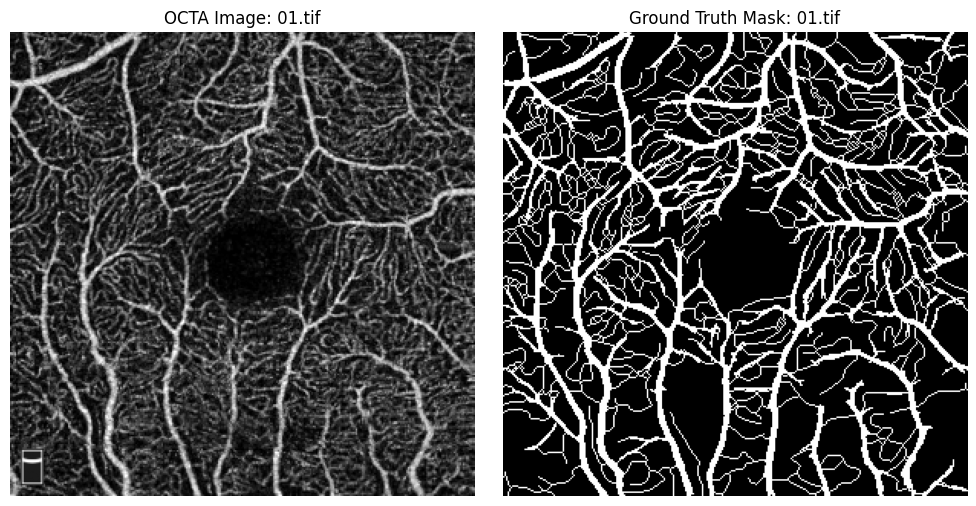

In [4]:
# Load first image and mask
img = cv2.imread(str(svc_imgs[0]), cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(str(svc_masks[0]), cv2.IMREAD_GRAYSCALE)

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title(f"OCTA Image: {svc_imgs[0].name}")
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title(f"Ground Truth Mask: {svc_masks[0].name}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Image Properties and Vessel Density Analysis: SVC Training Set

In [9]:
print(f"Image shape: {img.shape}")
print(f"Image dtype: {img.dtype}")
print(f"Image min/max: {img.min()}/{img.max()}")
print(f"\nMask shape: {mask.shape}")
print(f"Mask dtype: {mask.dtype}")
print(f"Mask unique values: {np.unique(mask)}")

# What fraction of pixels are vessels?
vessel_ratio = (mask > 0).sum() / mask.size
print(f"\nVessel pixels: {vessel_ratio:.1%} of image")

Image shape: (304, 304)
Image dtype: uint8
Image min/max: 0/255

Mask shape: (304, 304)
Mask dtype: uint8
Mask unique values: [  0 255]

Vessel pixels: 21.3% of image


Mean vessel ratio: 19.6%
Min vessel ratio:  13.6%
Max vessel ratio:  24.3%
Stdev vessel ratio:  2.9%


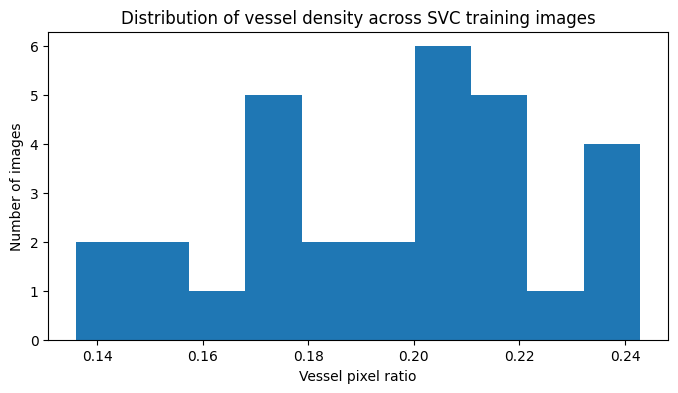

In [8]:
vessel_ratios = []
for mask_path in svc_masks:
    m = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    vessel_ratios.append((m > 0).sum() / m.size)

print(f"Mean vessel ratio: {np.mean(vessel_ratios):.1%}")
print(f"Min vessel ratio:  {np.min(vessel_ratios):.1%}")
print(f"Max vessel ratio:  {np.max(vessel_ratios):.1%}")
print(f"Stdev vessel ratio:  {np.std(vessel_ratios):.1%}")

plt.figure(figsize=(8, 4))
plt.hist(vessel_ratios, bins=10)
plt.xlabel("Vessel pixel ratio")
plt.ylabel("Number of images")
plt.title("Distribution of vessel density across SVC training images")
plt.show()

## Sample Images: SVC Training Set Overview

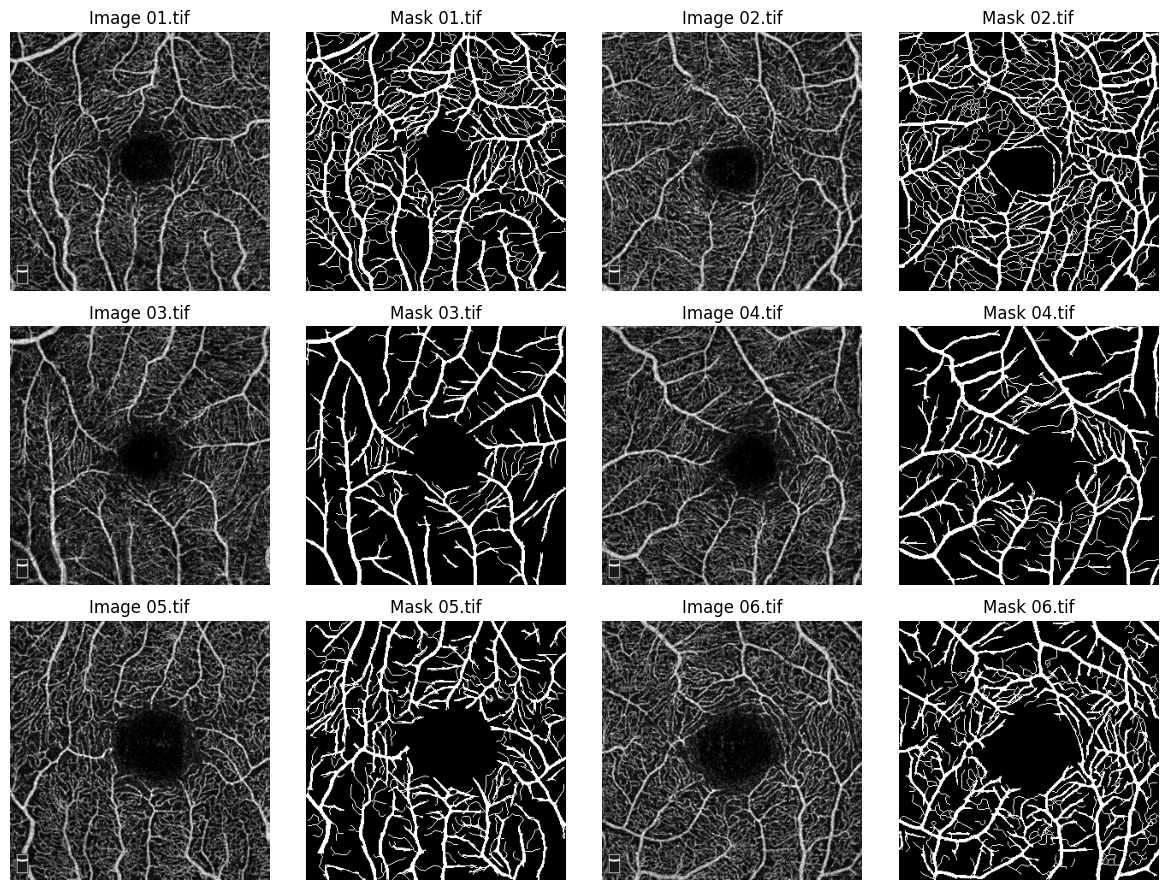

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for i in range(6):
    img = cv2.imread(str(svc_imgs[i]), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(svc_masks[i]), cv2.IMREAD_GRAYSCALE)
    
    axes[i//2, (i%2)*2].imshow(img, cmap='gray')
    axes[i//2, (i%2)*2].set_title(f"Image {svc_imgs[i].name}")
    axes[i//2, (i%2)*2].axis('off')
    
    axes[i//2, (i%2)*2+1].imshow(mask, cmap='gray')
    axes[i//2, (i%2)*2+1].set_title(f"Mask {svc_masks[i].name}")
    axes[i//2, (i%2)*2+1].axis('off')

plt.tight_layout()
plt.show()

## Visual Inspection: DVC Training Images

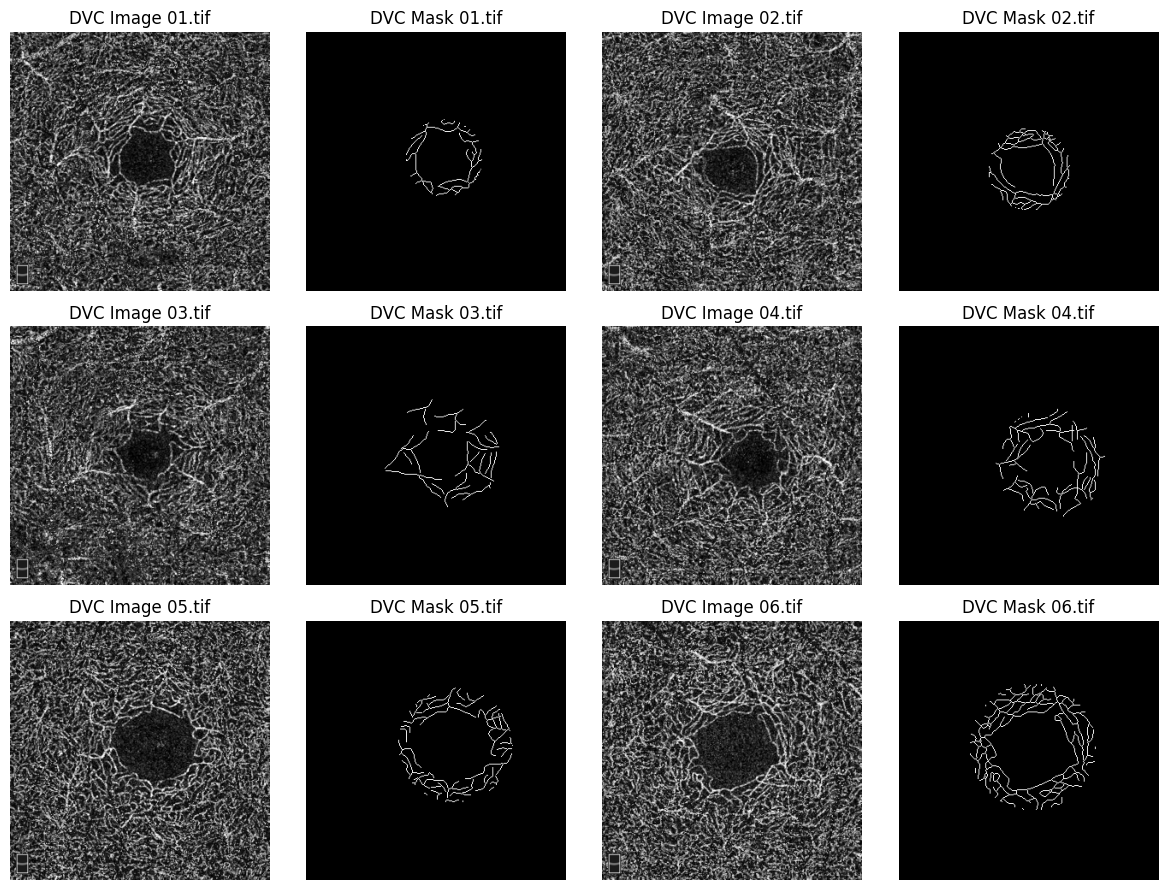

In [11]:
dvc_imgs = sorted(list((ROSE1_BASE / "DVC/train/img").glob("*.tif")))
dvc_masks = sorted(list((ROSE1_BASE / "DVC/train/gt").glob("*.tif")))

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for i in range(6):
    img = cv2.imread(str(dvc_imgs[i]), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(dvc_masks[i]), cv2.IMREAD_GRAYSCALE)
    
    axes[i//2, (i%2)*2].imshow(img, cmap='gray')
    axes[i//2, (i%2)*2].set_title(f"DVC Image {dvc_imgs[i].name}")
    axes[i//2, (i%2)*2].axis('off')
    
    axes[i//2, (i%2)*2+1].imshow(mask, cmap='gray')
    axes[i//2, (i%2)*2+1].set_title(f"DVC Mask {dvc_imgs[i].name}")
    axes[i//2, (i%2)*2+1].axis('off')

plt.tight_layout()
plt.show()

## Layer Comparison: SVC vs DVC

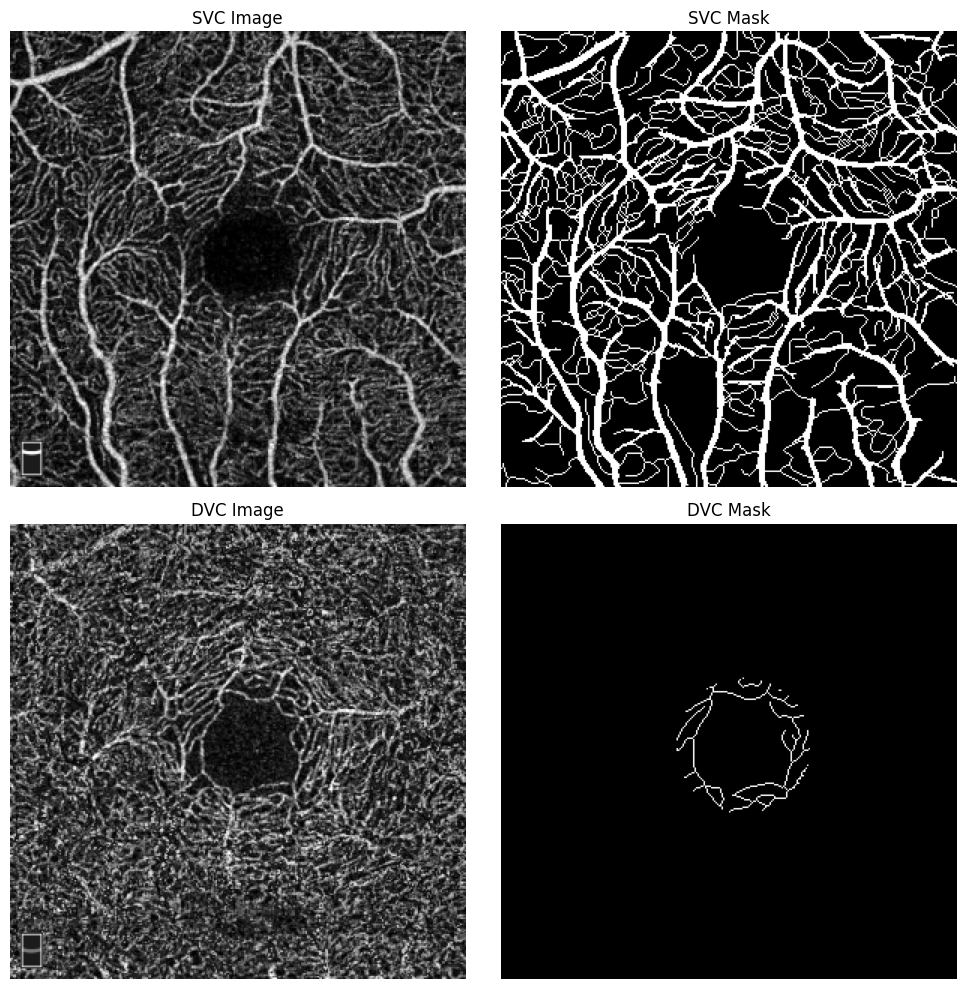

In [12]:
img_dvc = cv2.imread(str(dvc_imgs[0]), cv2.IMREAD_GRAYSCALE)
mask_dvc = cv2.imread(str(dvc_masks[0]), cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0,0].imshow(cv2.imread(str(svc_imgs[0]), cv2.IMREAD_GRAYSCALE), cmap='gray')
axes[0,0].set_title("SVC Image"); axes[0,0].axis('off')

axes[0,1].imshow(cv2.imread(str(svc_masks[0]), cv2.IMREAD_GRAYSCALE), cmap='gray')
axes[0,1].set_title("SVC Mask"); axes[0,1].axis('off')

axes[1,0].imshow(img_dvc, cmap='gray')
axes[1,0].set_title("DVC Image"); axes[1,0].axis('off')

axes[1,1].imshow(mask_dvc, cmap='gray')
axes[1,1].set_title("DVC Mask"); axes[1,1].axis('off')

plt.tight_layout()
plt.show()

## Exploring available folders

In [14]:
import os

for layer in ['SVC', 'DVC', 'SVC_DVC']:
    path = ROSE1_BASE / layer / 'train'
    folders = os.listdir(path)
    print(f"{layer}: {folders}")

SVC: ['gt', 'img', 'thick_gt', 'thick_gt_converted', 'thin_gt']
DVC: ['.DS_Store', 'gt', 'img']
SVC_DVC: ['gt', 'img']


## Exploring SVC more

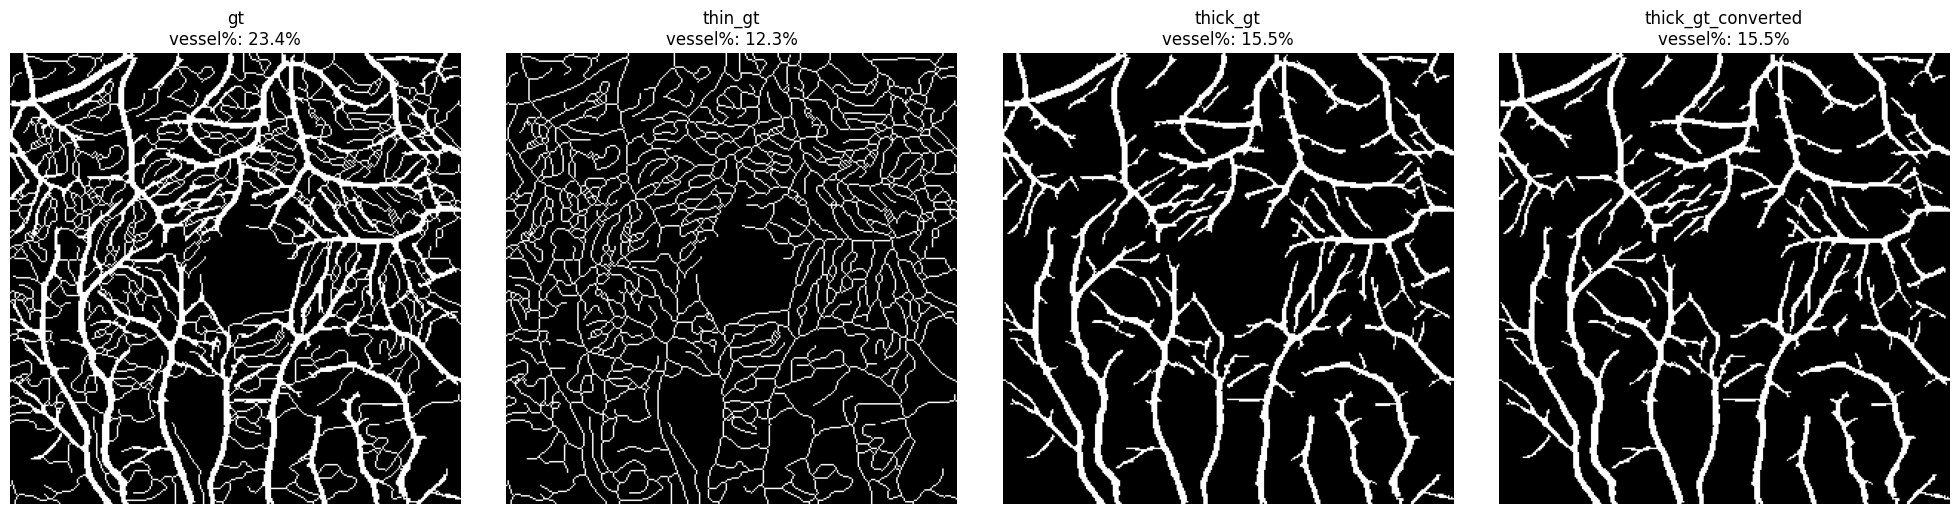

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

gt = cv2.imread(str(ROSE1_BASE / "SVC/train/gt/01.tif"), cv2.IMREAD_GRAYSCALE)
thin = cv2.imread(str(ROSE1_BASE / "SVC/train/thin_gt/01.tif"), cv2.IMREAD_GRAYSCALE)
thick = cv2.imread(str(ROSE1_BASE / "SVC/train/thick_gt/01.tif"), cv2.IMREAD_GRAYSCALE)
thick_conv = cv2.imread(str(ROSE1_BASE / "SVC/train/thick_gt_converted/01.tif"), cv2.IMREAD_GRAYSCALE)

for ax, img, title in zip(axes, [gt, thin, thick, thick_conv], 
                          ['gt', 'thin_gt', 'thick_gt', 'thick_gt_converted']):
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{title}\nvessel%: {(img>0).mean():.1%}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Annotation Type Decision
Using `gt` (pixel-level, all vessels, ~23% vessel density) as ground truth for training and evaluation.
- `thin_gt` = centerline only, not suitable for pixel-wise metrics
- `thick_gt` = large vessels only, incomplete
- `thick_gt_converted` = same as thick_gt, different format